In [1]:
from torchvision import transforms,models,datasets
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from pathlib import Path
import torch
import numpy as np
from PIL import Image
import os
from torch import nn
from torchvision.models import vit_b_16
import torch.optim as optim
# from ..opt import read_args
from five_dataset import MyDataset
from models.vit import DualViT
from models.resnet18 import DualResNet
from models.vgg import DualVgg16
import time
from torch.utils.data import random_split
from plot_image import plot_image
from torch.utils.tensorboard import SummaryWriter
from main import load_dataset,criterion1,criterion2
import random
random.seed(42) 


_,_,test_dataset=load_dataset(data_argumentation=False)


/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


this is label2 counter:  Counter({0: 6093, 3: 4407, 1: 1656, 2: 495})
max label2 count:  6093
total num before first balance:  12651
Deep:  6093
Lobar:  1656
Subtentorial:  495
total num after first balance:  21408
counter after first balance:  Counter({0: 6093, 2: 5940, 1: 4968, 3: 4407})
total num before second balance:  21408
no tumor:  4407
tumor:  17001
max label1 count:  17001
total num after balance:  30222
no tumor:  13221
tumor:  17001


In [2]:
from main import select_model
def test(model_path,model_type):
    device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)
    model=select_model(model_type,True)
    model.load_state_dict(torch.load(model_path))
    ##Testing
    model.eval()
    model.to(device)
    start_time = time.time()
# 
    TP=0
    TN=0
    FP=0
    FN=0
    # 
    C00=0
    C01=0   
    C02=0
    C10=0
    C11=0
    C12=0
    C20=0
    C21=0
    C22=0
    positive_count=0
    negative_count=0
    deep_count=0
    lobar_count=0
    subtentorial_count=0
    # {'Deep': 0, 'Lobar': 1, 'Subtentorial': 2}
    with torch.no_grad():
        running_loss = 0.
        running_corrects = 0
        for index, inputs  in enumerate(test_dataloader):
            image, labels1,labels2 = inputs['pixel_values'],inputs['label1'],inputs['label2']
            image = image.to(device)
            labels1= labels1.to(device)
            labels2= labels2.to(device)
            outputs1,outputs2  = model(image)
            _, preds1 = torch.max(outputs1, 1)
            _, preds2 = torch.max(outputs2, 1)
            # batch loss
            loss1 = criterion1(outputs1, labels1)
            loss2 = criterion2(outputs2, labels2)
            # loss = loss1 + loss2
            loss = loss1 + loss2
            # total loss
            running_loss += loss.item() * image.size(0)
            # positive or negetive
            running_corrects += torch.sum(preds1 == labels1.data)
            # confusion matrix for class1
            for i in range(len(preds1)):
                if preds1[i]==labels1[i]:
                    # no: 0, yes: 1
                    if preds1[i]==0:
                        negative_count+=1
                        TP+=1
                    else:
                        positive_count+=1
                        TN+=1
                else:
                    if preds1[i]==0:
                        positive_count+=1
                        FP+=1
                    else:
                        negative_count+=1
                        FN+=1
            # confusion matrix for class2
            for i in range(len(preds2)):
                if preds2[i]==labels2[i]:
                    if preds2[i]==0:
                        C00+=1
                        deep_count+=1
                    elif preds2[i]==1:
                        C11+=1
                        lobar_count+=1
                    elif preds2[i]==2:
                        C22+=1
                        subtentorial_count+=1
                # predict 和 label不一样
                else:
                    # 后一个数字是预测值，前一个数字是真实值
                    if preds2[i]==0:
                        if labels2[i]==1:
                            lobar_count+=1
                            C10+=1
                        elif labels2[i]==2:
                            subtentorial_count+=1
                            C20+=1
                    elif preds2[i]==1:
                        if labels2[i]==0:
                            deep_count+=1
                            C11+=1
                        elif labels2[i]==2:
                            subtentorial_count+=1
                            C21+=1
                    elif preds2[i]==2:
                        if labels2[i]==0:
                            deep_count+=1
                            C02+=1
                        elif labels2[i]==1:
                            lobar_count+=1
                            C12+=1

            running_corrects += torch.sum(preds2 == labels2.data)
            if index == 0:
                print("label1:",labels1.tolist())
                print("preds1:",preds1.tolist())
                print("label2:",labels2.tolist())
                print("preds2:",preds2.tolist())
                plot_image(image, labels1.tolist(), labels2.tolist(), preds1.tolist(), preds2.tolist())
        epoch_loss = running_loss / len(test_dataset)
        epoch_acc = running_corrects / (2* len(test_dataset)) * 100.
        print('[Test] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.
            format(epoch_loss, epoch_acc, time.time() - start_time))
    print('TP:',TP)
    print('TN:',TN)
    print('FP:',FP)
    print('FN:',FN)
    print("deep count",deep_count)
    print("lobar count",lobar_count)
    print("subtentorial count",subtentorial_count)
    print("positive count",positive_count)
    print("negative count",negative_count)
    return TP,TN,FP,FN,C00,C01,C02,C10,C11,C12,C20,C21,C22


## ViT augumented

/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_L_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_L_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


label1: [0, 1, 1, 1]
preds1: [0, 1, 1, 1]
label2: [3, 2, 2, 0]
preds2: [3, 2, 2, 0]


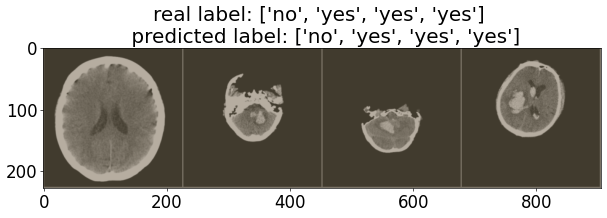

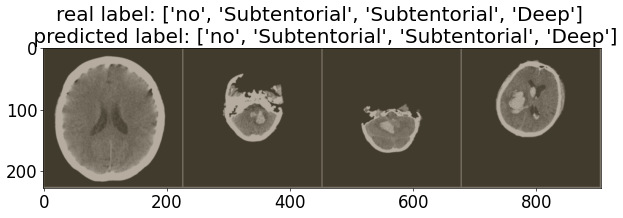

[Test] Loss: 0.0337 Acc: 99.4211% Time: 16.9579s
TP: 1325
TN: 1697
FP: 0
FN: 1
deep count 592
lobar count 491
subtentorial count 614
positive count 1697
negative count 1326
TP: 1325
TN: 1697
FP: 0
FN: 1
Accuracy: 0.9996692027786966
Precision: 1.0
Recall: 0.9992458521870287
F1: 0.999622783855149
Specificity: 1.0
C00: 591
C01: 0
C02: 0
C10: 1
C11: 491
C12: 0
C20: 31
C21: 0
C22: 583
Accuracy: 0.981143193871538
Precision: 0.9486356340288925
Recall: 1.0
F1: 0.9736408566721582
Specificity: 1.0


In [3]:

home_dir='/disk8t/jialiangfan/trained_models/'


# vit model
model_name='dataset-epoche_20-model_type_10-pretrained_True-argumentation_True-batch_size_32-optimizer_type-2.pth'
# model_name='dataset2-epoche_50-model_type_2-pretrained_False-argumentation_True-batch_size_32-optimizer_type-0.pth'
model_type=10
TP,TN,FP,FN, C00,C01,C02,C10,C11,C12,C20,C21,C22 =test(home_dir+model_name,model_type)

# draw the confusion matrix
print('TP:',TP)
print('TN:',TN)
print('FP:',FP)
print('FN:',FN)

print('Accuracy:',(TP+TN)/(TP+TN+FP+FN))
print('Precision:',TP/(TP+FP))
print('Recall:',TP/(TP+FN))
print('F1:',2*TP/(2*TP+FP+FN))
print('Specificity:',TN/(TN+FP))

print('C00:',C00)
print('C01:',C01)
print('C02:',C02)
print('C10:',C10)
print('C11:',C11)
print('C12:',C12)
print('C20:',C20)
print('C21:',C21)
print('C22:',C22)

print('Accuracy:',(C00+C11+C22)/(C00+C01+C02+C10+C11+C12+C20+C21+C22))
print('Precision:',C00/(C00+C10+C20))
print('Recall:',C00/(C00+C01+C02))
print('F1:',2*C00/(2*C00+C01+C02+C10+C20))
print('Specificity:',(C11+C22)/(C11+C12+C21+C22))


## Draw the confusion matrix for ViT

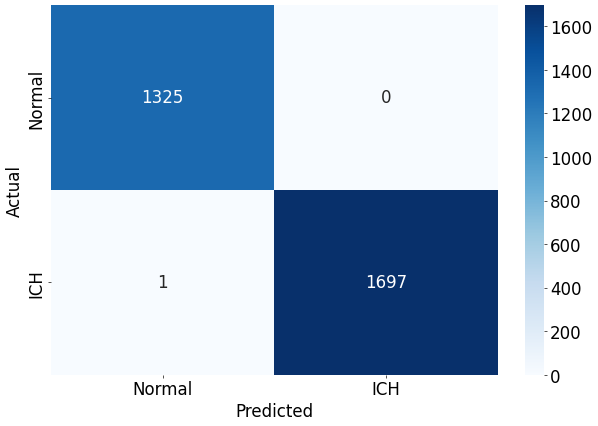

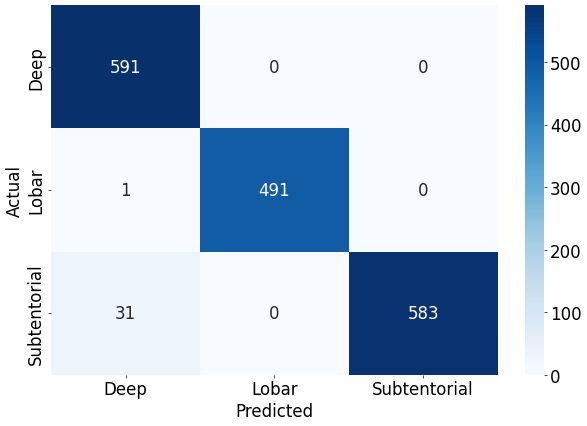

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# 创建混淆矩阵
confusion_matrix1 = np.array([[TP, FP], [FN, TN]])
font_dict={'family':'Times New Roman','size':15}
labels=['Normal','ICH']
# 使用seaborn绘制混淆矩阵
sns.heatmap(confusion_matrix1, annot=True, fmt='d', cmap='Blues',xticklabels=labels, yticklabels=labels)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('figs/confusion_matrix_class1.png',dpi=300,bbox_inches='tight')
plt.show()


# 创建混淆矩阵
confusion_matrix2 = np.array([[C00, C01,C02], [C10, C11,C12],[C20, C21,C22]])
font_dict={'family':'Times New Roman','size':15}
labels=['Deep','Lobar','Subtentorial']
# {0:'Deep',1:'Lobar',2:'Subtentorial',3:'no'}
# 使用seaborn绘制混淆矩阵
sns.heatmap(confusion_matrix2, annot=True, fmt='d', cmap='Blues',xticklabels=labels, yticklabels=labels)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('figs/confusion_matrix_class2.png',dpi=300,bbox_inches='tight')
plt.show()

## Vit without augumentation

/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_L_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_L_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


label1: [0, 1, 1, 1]
preds1: [0, 1, 1, 1]
label2: [3, 2, 2, 0]
preds2: [3, 2, 2, 0]


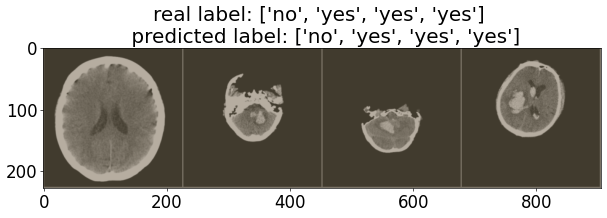

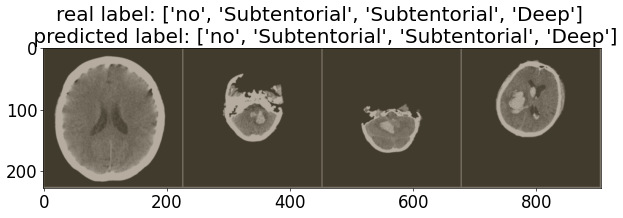

[Test] Loss: 0.0901 Acc: 98.4453% Time: 16.7544s
TP: 1301
TN: 1697
FP: 0
FN: 25
deep count 592
lobar count 491
subtentorial count 614
positive count 1697
negative count 1326
TP: 1301
TN: 1697
FP: 0
FN: 25
Accuracy: 0.9917300694674165
Precision: 1.0
Recall: 0.9811463046757164
F1: 0.9904834411876665
Specificity: 1.0
C00: 585
C01: 0
C02: 4
C10: 14
C11: 480
C12: 0
C20: 25
C21: 0
C22: 589
Accuracy: 0.9746611667648792
Precision: 0.9375
Recall: 0.9932088285229203
F1: 0.964550700741962
Specificity: 1.0


In [5]:

home_dir='/disk8t/jialiangfan/trained_models/'


# vit model
model_name='dataset-epoche_20-model_type_10-pretrained_True-argumentation_False-batch_size_32-optimizer_type-2.pth'
# model_name='dataset2-epoche_50-model_type_2-pretrained_False-argumentation_True-batch_size_32-optimizer_type-0.pth'
model_type=10
TP,TN,FP,FN, C00,C01,C02,C10,C11,C12,C20,C21,C22 =test(home_dir+model_name,model_type)

# draw the confusion matrix
print('TP:',TP)
print('TN:',TN)
print('FP:',FP)
print('FN:',FN)

print('Accuracy:',(TP+TN)/(TP+TN+FP+FN))
print('Precision:',TP/(TP+FP))
print('Recall:',TP/(TP+FN))
print('F1:',2*TP/(2*TP+FP+FN))
print('Specificity:',TN/(TN+FP))

print('C00:',C00)
print('C01:',C01)
print('C02:',C02)
print('C10:',C10)
print('C11:',C11)
print('C12:',C12)
print('C20:',C20)
print('C21:',C21)
print('C22:',C22)

print('Accuracy:',(C00+C11+C22)/(C00+C01+C02+C10+C11+C12+C20+C21+C22))
print('Precision:',C00/(C00+C10+C20))
print('Recall:',C00/(C00+C01+C02))
print('F1:',2*C00/(2*C00+C01+C02+C10+C20))
print('Specificity:',(C11+C22)/(C11+C12+C21+C22))


## ResNet augumented

label1: [0, 1, 1, 1]
preds1: [0, 1, 1, 1]
label2: [3, 2, 2, 0]
preds2: [3, 2, 2, 0]


/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


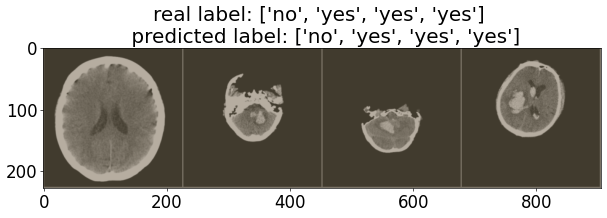

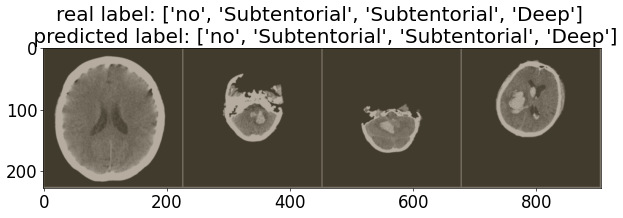

[Test] Loss: 0.0098 Acc: 99.8677% Time: 5.3358s
TP: 1326
TN: 1697
FP: 0
FN: 0
deep count 592
lobar count 491
subtentorial count 614
positive count 1697
negative count 1326
TP: 1326
TN: 1697
FP: 0
FN: 0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Specificity: 1.0
C00: 584
C01: 0
C02: 7
C10: 0
C11: 492
C12: 0
C20: 0
C21: 0
C22: 614
Accuracy: 0.995875073659399
Precision: 1.0
Recall: 0.988155668358714
F1: 0.9940425531914894
Specificity: 1.0


In [6]:

home_dir='/disk8t/jialiangfan/trained_models/'


# resnet model18
model_name='dataset-epoche_20-model_type_1-pretrained_True-argumentation_True-batch_size_32-optimizer_type-2.pth'
model_type=1
TP,TN,FP,FN, C00,C01,C02,C10,C11,C12,C20,C21,C22 =test(home_dir+model_name,model_type=model_type)

# draw the confusion matrix
print('TP:',TP)
print('TN:',TN)
print('FP:',FP)
print('FN:',FN)

print('Accuracy:',(TP+TN)/(TP+TN+FP+FN))
print('Precision:',TP/(TP+FP))
print('Recall:',TP/(TP+FN))
print('F1:',2*TP/(2*TP+FP+FN))
print('Specificity:',TN/(TN+FP))

print('C00:',C00)
print('C01:',C01)
print('C02:',C02)
print('C10:',C10)
print('C11:',C11)
print('C12:',C12)
print('C20:',C20)
print('C21:',C21)
print('C22:',C22)

print('Accuracy:',(C00+C11+C22)/(C00+C01+C02+C10+C11+C12+C20+C21+C22))
print('Precision:',C00/(C00+C10+C20))
print('Recall:',C00/(C00+C01+C02))
print('F1:',2*C00/(2*C00+C01+C02+C10+C20))
print('Specificity:',(C11+C22)/(C11+C12+C21+C22))

## VGG augumented

/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


label1: [0, 1, 1, 1]
preds1: [0, 1, 1, 1]
label2: [3, 2, 2, 0]
preds2: [3, 2, 2, 0]


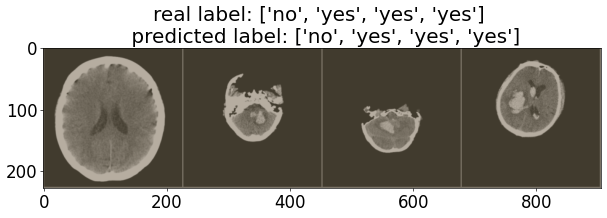

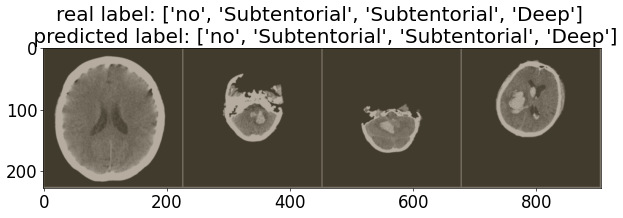

[Test] Loss: 0.0073 Acc: 99.8511% Time: 8.1464s
TP: 1326
TN: 1697
FP: 0
FN: 0
deep count 592
lobar count 491
subtentorial count 614
positive count 1697
negative count 1326
TP: 1326
TN: 1697
FP: 0
FN: 0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Specificity: 1.0
C00: 586
C01: 0
C02: 6
C10: 0
C11: 491
C12: 0
C20: 3
C21: 0
C22: 611
Accuracy: 0.99469652327637
Precision: 0.9949066213921901
Recall: 0.9898648648648649
F1: 0.9923793395427604
Specificity: 1.0


/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


In [7]:

home_dir='/disk8t/jialiangfan/trained_models/'


# resnet model
model_name='dataset-epoche_20-model_type_2-pretrained_True-argumentation_True-batch_size_32-optimizer_type-2.pth'
# model_name='dataset2-epoche_50-model_type_2-pretrained_False-argumentation_True-batch_size_32-optimizer_type-0.pth'
#  {0: ViT, 1: ResNet, 2:VGG16, 3:alexnet, 4:squeezenet, 5: ResNet34, 6: ResNet50,7:DenseNet}
model_type=2
TP,TN,FP,FN, C00,C01,C02,C10,C11,C12,C20,C21,C22 =test(home_dir+model_name,model_type=model_type)

# draw the confusion matrix
print('TP:',TP)
print('TN:',TN)
print('FP:',FP)
print('FN:',FN)

print('Accuracy:',(TP+TN)/(TP+TN+FP+FN))
print('Precision:',TP/(TP+FP))
print('Recall:',TP/(TP+FN))
print('F1:',2*TP/(2*TP+FP+FN))
print('Specificity:',TN/(TN+FP))

print('C00:',C00)
print('C01:',C01)
print('C02:',C02)
print('C10:',C10)
print('C11:',C11)
print('C12:',C12)
print('C20:',C20)
print('C21:',C21)
print('C22:',C22)

print('Accuracy:',(C00+C11+C22)/(C00+C01+C02+C10+C11+C12+C20+C21+C22))
print('Precision:',C00/(C00+C10+C20))
print('Recall:',C00/(C00+C01+C02))
print('F1:',2*C00/(2*C00+C01+C02+C10+C20))
print('Specificity:',(C11+C22)/(C11+C12+C21+C22))

In [8]:
## alexnet


## AlexNet pretrained


/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


label1: [0, 1, 1, 1]
preds1: [0, 1, 1, 1]
label2: [3, 2, 2, 0]
preds2: [3, 2, 2, 0]


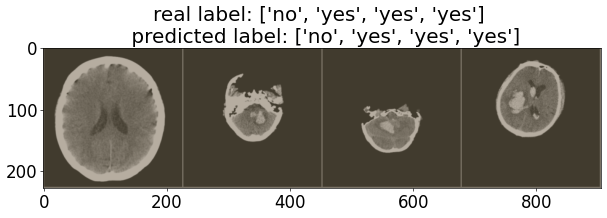

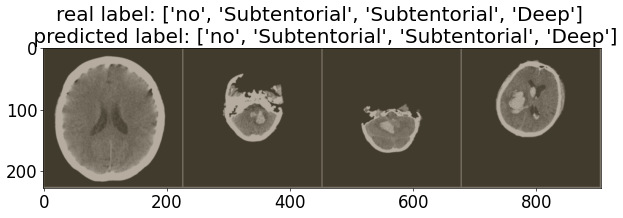

[Test] Loss: 0.0148 Acc: 99.7354% Time: 5.0283s
TP: 1326
TN: 1697
FP: 0
FN: 0
deep count 592
lobar count 491
subtentorial count 614
positive count 1697
negative count 1326
TP: 1326
TN: 1697
FP: 0
FN: 0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Specificity: 1.0
C00: 576
C01: 0
C02: 7
C10: 0
C11: 500
C12: 0
C20: 0
C21: 0
C22: 614
Accuracy: 0.995875073659399
Precision: 1.0
Recall: 0.9879931389365352
F1: 0.993960310612597
Specificity: 1.0


In [9]:

home_dir='/disk8t/jialiangfan/trained_models/'
model_name='dataset-epoche_20-model_type_3-pretrained_True-argumentation_True-batch_size_32-optimizer_type-2.pth'
#  {0: ViT, 1: ResNet, 2:VGG16, 3:alexnet, 4:squeezenet, 5: ResNet34, 6: ResNet50,7:DenseNet}
model_type=3
TP,TN,FP,FN, C00,C01,C02,C10,C11,C12,C20,C21,C22 =test(home_dir+model_name,model_type=model_type)

# draw the confusion matrix
print('TP:',TP)
print('TN:',TN)
print('FP:',FP)
print('FN:',FN)

print('Accuracy:',(TP+TN)/(TP+TN+FP+FN))
print('Precision:',TP/(TP+FP))
print('Recall:',TP/(TP+FN))
print('F1:',2*TP/(2*TP+FP+FN))
print('Specificity:',TN/(TN+FP))

print('C00:',C00)
print('C01:',C01)
print('C02:',C02)
print('C10:',C10)
print('C11:',C11)
print('C12:',C12)
print('C20:',C20)
print('C21:',C21)
print('C22:',C22)

print('Accuracy:',(C00+C11+C22)/(C00+C01+C02+C10+C11+C12+C20+C21+C22))
print('Precision:',C00/(C00+C10+C20))
print('Recall:',C00/(C00+C01+C02))
print('F1:',2*C00/(2*C00+C01+C02+C10+C20))
print('Specificity:',(C11+C22)/(C11+C12+C21+C22))

## SqueezeNet


label1: [0, 1, 1, 1]
preds1: [0, 1, 1, 1]
label2: [3, 2, 2, 0]
preds2: [3, 2, 2, 0]


/home/jialiangfan/miniconda3/envs/medical/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


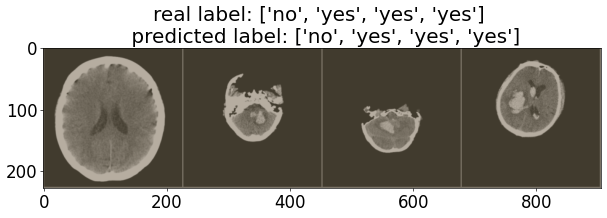

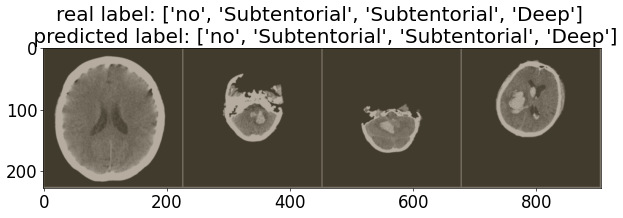

[Test] Loss: 0.0366 Acc: 99.3384% Time: 5.3052s
TP: 1323
TN: 1697
FP: 0
FN: 3
deep count 591
lobar count 491
subtentorial count 614
positive count 1697
negative count 1326
TP: 1323
TN: 1697
FP: 0
FN: 3
Accuracy: 0.9990076083360899
Precision: 1.0
Recall: 0.997737556561086
F1: 0.9988674971687429
Specificity: 1.0
C00: 580
C01: 0
C02: 8
C10: 22
C11: 472
C12: 0
C20: 0
C21: 0
C22: 614
Accuracy: 0.9823113207547169
Precision: 0.9634551495016611
Recall: 0.9863945578231292
F1: 0.9747899159663865
Specificity: 1.0


In [11]:

home_dir='/disk8t/jialiangfan/trained_models/'
model_name='dataset-epoche_20-model_type_4-pretrained_True-argumentation_True-batch_size_32-optimizer_type-2.pth'
#  {0: ViT, 1: ResNet, 2:VGG16, 3:alexnet, 4:squeezenet, 5: ResNet34, 6: ResNet50,7:DenseNet}
model_type=4
TP,TN,FP,FN, C00,C01,C02,C10,C11,C12,C20,C21,C22 =test(home_dir+model_name,model_type=model_type)

# draw the confusion matrix
print('TP:',TP)
print('TN:',TN)
print('FP:',FP)
print('FN:',FN)

print('Accuracy:',(TP+TN)/(TP+TN+FP+FN))
print('Precision:',TP/(TP+FP))
print('Recall:',TP/(TP+FN))
print('F1:',2*TP/(2*TP+FP+FN))
print('Specificity:',TN/(TN+FP))

print('C00:',C00)
print('C01:',C01)
print('C02:',C02)
print('C10:',C10)
print('C11:',C11)
print('C12:',C12)
print('C20:',C20)
print('C21:',C21)
print('C22:',C22)

print('Accuracy:',(C00+C11+C22)/(C00+C01+C02+C10+C11+C12+C20+C21+C22))
print('Precision:',C00/(C00+C10+C20))
print('Recall:',C00/(C00+C01+C02))
print('F1:',2*C00/(2*C00+C01+C02+C10+C20))
print('Specificity:',(C11+C22)/(C11+C12+C21+C22))

## Densenet 

label1: [0, 1, 1, 1]
preds1: [0, 1, 1, 1]
label2: [3, 2, 2, 0]
preds2: [3, 2, 2, 0]


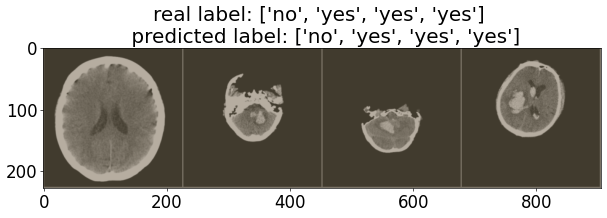

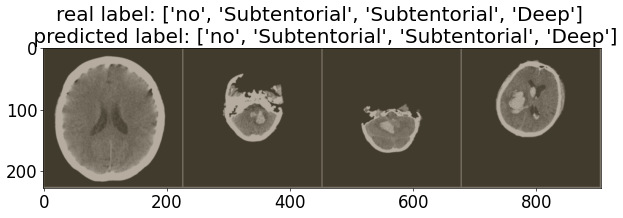

[Test] Loss: 0.0061 Acc: 99.9008% Time: 9.0958s
TP: 1326
TN: 1697
FP: 0
FN: 0
deep count 592
lobar count 491
subtentorial count 614
positive count 1697
negative count 1326
TP: 1326
TN: 1697
FP: 0
FN: 0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Specificity: 1.0
C00: 586
C01: 0
C02: 5
C10: 0
C11: 492
C12: 0
C20: 0
C21: 0
C22: 614
Accuracy: 0.9970536240424278
Precision: 1.0
Recall: 0.9915397631133672
F1: 0.9957519116397621
Specificity: 1.0


: 

In [13]:

home_dir='/disk8t/jialiangfan/trained_models/'
model_name='dataset-epoche_20-model_type_7-pretrained_True-argumentation_True-batch_size_32-optimizer_type-2.pth'
#  {0: ViT, 1: ResNet, 2:VGG16, 3:alexnet, 4:squeezenet, 5: ResNet34, 6: ResNet50,7:DenseNet}
model_type=7
TP,TN,FP,FN, C00,C01,C02,C10,C11,C12,C20,C21,C22 =test(home_dir+model_name,model_type=model_type)

# draw the confusion matrix
print('TP:',TP)
print('TN:',TN)
print('FP:',FP)
print('FN:',FN)

print('Accuracy:',(TP+TN)/(TP+TN+FP+FN))
print('Precision:',TP/(TP+FP))
print('Recall:',TP/(TP+FN))
print('F1:',2*TP/(2*TP+FP+FN))
print('Specificity:',TN/(TN+FP))

print('C00:',C00)
print('C01:',C01)
print('C02:',C02)
print('C10:',C10)
print('C11:',C11)
print('C12:',C12)
print('C20:',C20)
print('C21:',C21)
print('C22:',C22)

print('Accuracy:',(C00+C11+C22)/(C00+C01+C02+C10+C11+C12+C20+C21+C22))
print('Precision:',C00/(C00+C10+C20))
print('Recall:',C00/(C00+C01+C02))
print('F1:',2*C00/(2*C00+C01+C02+C10+C20))
print('Specificity:',(C11+C22)/(C11+C12+C21+C22))